# Análise da frequência e valor dos inscritos

## 1. Carregamento de libs e definição de funções

In [1]:
import pandas as pd
import sqlalchemy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import cluster
from sklearn import preprocessing

In [2]:
def import_query(path):
    with open(path) as open_file:
        return open_file.read()

## 2. Carregamento da base de dados

In [3]:
engine = sqlalchemy.create_engine("sqlite:///../../data/loyalty-system/database.db")
query = import_query("frequencia_valor.sql")
df = pd.read_sql(query, engine)
df = df[df["qtdePontosPos"] < 4000]
df.head()

,IdCliente,qtdFrequencia,qtdePontosPos,qtdePontosAbs
0,820c0e06-c405-4979-8975-ecfa17abb0f9,25,2400,7400
1,6313ceac-7806-4d34-aedd-476eed7c853a,24,2577,10577
2,4fade907-6e0f-4581-a674-aad6622b1b10,22,1761,1761
3,961622c3-3c29-4fa1-88d2-4f408d6d6ebb,19,1506,2506
4,5ff083a7-e818-4367-bda5-a9cee8dec654,19,1253,7253


In [4]:
minMax = preprocessing.MinMaxScaler()
x = minMax.fit_transform(df[["qtdFrequencia", "qtdePontosPos"]])
x[:5]

array([[1.        , 0.79993331],
       [0.95833333, 0.85895298],
       [0.875     , 0.58686229],
       [0.75      , 0.50183394],
       [0.75      , 0.41747249]])

## 3. Análise inicial da base de dados

### 3.1. Gráfico da frequência e valor inicial

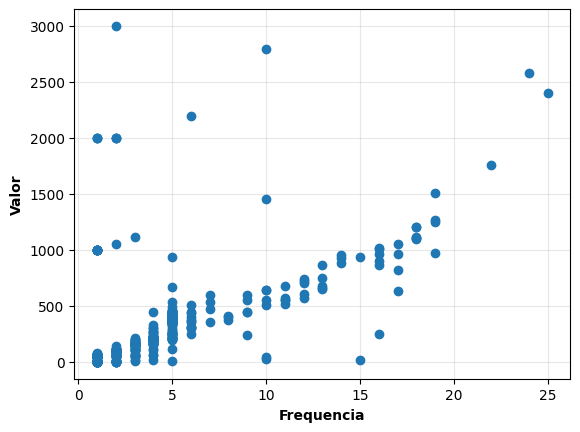

In [5]:
plt.Figure(figsize=(12, 6))
plt.plot(df['qtdFrequencia'], df['qtdePontosPos'], 'o')
plt.grid(True, alpha=.3)
plt.xlabel("Frequencia", fontweight="bold")
plt.ylabel("Valor", fontweight="bold")
plt.show()

## 4. Clusterização via K-Means

### 4.1. Construção da clusterização

In [6]:
kmeans = cluster.KMeans(n_clusters=5, random_state=42, max_iter=1000)
kmeans.fit(x)
df['cluster'] = kmeans.labels_

df.head()

,IdCliente,qtdFrequencia,qtdePontosPos,qtdePontosAbs,cluster
0,820c0e06-c405-4979-8975-ecfa17abb0f9,25,2400,7400,2
1,6313ceac-7806-4d34-aedd-476eed7c853a,24,2577,10577,2
2,4fade907-6e0f-4581-a674-aad6622b1b10,22,1761,1761,2
3,961622c3-3c29-4fa1-88d2-4f408d6d6ebb,19,1506,2506,4
4,5ff083a7-e818-4367-bda5-a9cee8dec654,19,1253,7253,4


In [7]:
df.groupby(by="cluster")["IdCliente"].count()

cluster
0    232
1    435
2      3
3      9
4     45
Name: IdCliente, dtype: int64

### 4.2. Geração de gráfico com clusterização

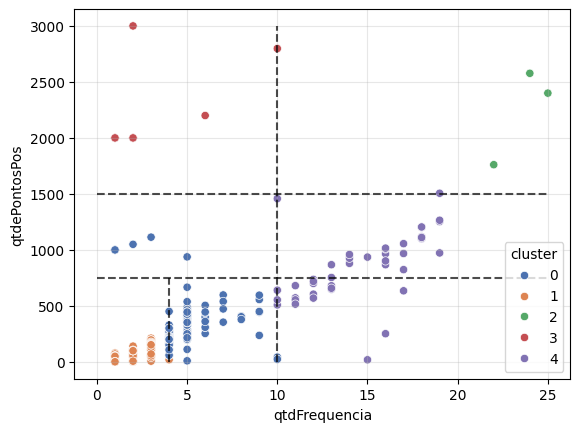

In [19]:
plt.Figure(figsize=(12, 6))

sns.scatterplot(data=df, x="qtdFrequencia", y="qtdePontosPos", hue="cluster", palette="deep")

plt.hlines(y=1500, xmin=0, xmax=25, color="black", linestyles="dashed", alpha=.7)
plt.hlines(y=750, xmin=0, xmax=25, color="black", linestyles="dashed", alpha=.7)

plt.vlines(x=4, ymin=0, ymax=750, color="black", linestyles="dashed", alpha=.7)
plt.vlines(x=10, ymin=0, ymax=3000, color="black", linestyles="dashed", alpha=.7)

plt.grid(True, alpha=.3)

## 5. Clusterização manual

In [23]:
engine = sqlalchemy.create_engine("sqlite:///../../data/loyalty-system/database.db")
query = import_query("frequencia_valor.sql")
df_manual = pd.read_sql(query, engine)
df_manual = df_manual[df_manual["qtdePontosPos"] < 4000]
df_manual.head()

,idCliente,qtdFrequencia,qtdePontosPos,qtdePontosAbs,cluster
0,820c0e06-c405-4979-8975-ecfa17abb0f9,25,2400,7400,EFICIENTES
1,6313ceac-7806-4d34-aedd-476eed7c853a,24,2577,10577,EFICIENTES
2,4fade907-6e0f-4581-a674-aad6622b1b10,22,1761,1761,EFICIENTES
3,961622c3-3c29-4fa1-88d2-4f408d6d6ebb,19,1506,2506,EFICIENTES
4,5ff083a7-e818-4367-bda5-a9cee8dec654,19,1253,7253,ESFORCADO


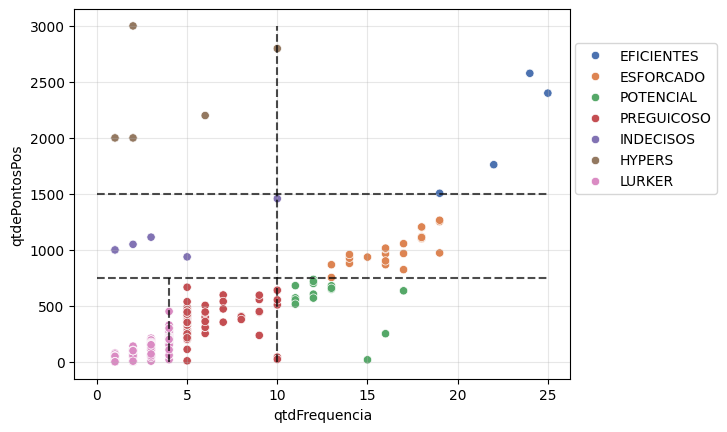

In [26]:
plt.Figure(figsize=(12, 6))

sns.scatterplot(data=df_manual, x="qtdFrequencia", y="qtdePontosPos", hue="cluster", palette="deep")

plt.hlines(y=1500, xmin=0, xmax=25, color="black", linestyles="dashed", alpha=.7)
plt.hlines(y=750, xmin=0, xmax=25, color="black", linestyles="dashed", alpha=.7)

plt.vlines(x=4, ymin=0, ymax=750, color="black", linestyles="dashed", alpha=.7)
plt.vlines(x=10, ymin=0, ymax=3000, color="black", linestyles="dashed", alpha=.7)

plt.legend(loc=(1.01, 0.5))

plt.grid(True, alpha=.3)